## Fase 2 (inicio del laboratorio programado)

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

import warnings
warnings.filterwarnings("ignore")

In [6]:
## configuracion de grafos

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [7]:
## carga de csv
## lectura del archivo

df = pd.read_csv("../data/adult.csv")

In [8]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [9]:
## dimension del data set 

print("Filas y columnas:")
print(df.shape)

Filas y columnas:
(32561, 15)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [11]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [12]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

### sección del EDA

In [13]:
## cantidad de datos duplicados 

print("Duplicados:", df.duplicated().sum())

Duplicados: 24


In [14]:
## eliminacion de duplicados 
df = df.drop_duplicates()

In [15]:
## verificacion posterior 
print("Nuevo tamaño del dataset:")
print(df.shape)

Nuevo tamaño del dataset:
(32537, 15)


In [16]:
## Analisis de la variable objetivo 

df["income"].value_counts()

income
<=50K    24698
>50K      7839
Name: count, dtype: int64

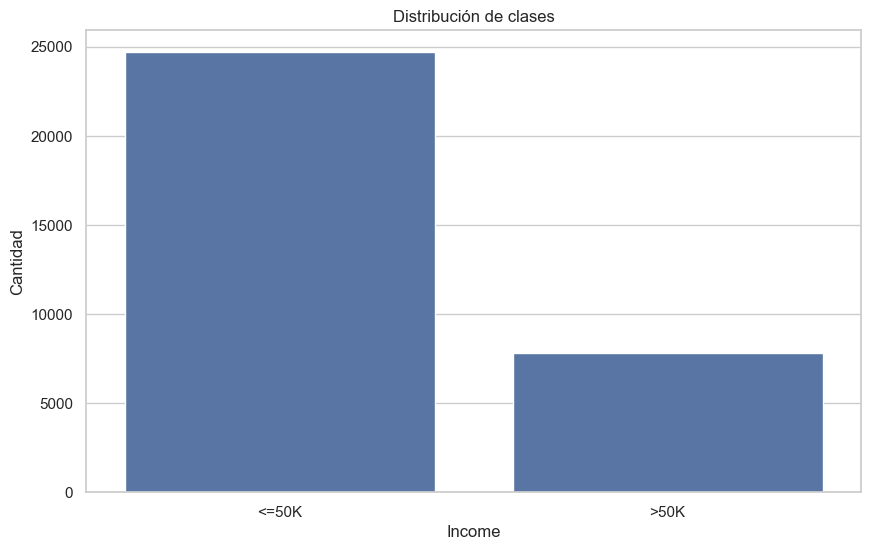

In [17]:
## visualizacion de clases 

sns.countplot(data=df, x="income")

plt.title("Distribución de clases")
plt.xlabel("Income")
plt.ylabel("Cantidad")

plt.show()

### Selección y análisis del dataset

In [18]:
## Análisis de variables numéricas
## Selección de variables numéricas

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

print(numeric_columns)

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')


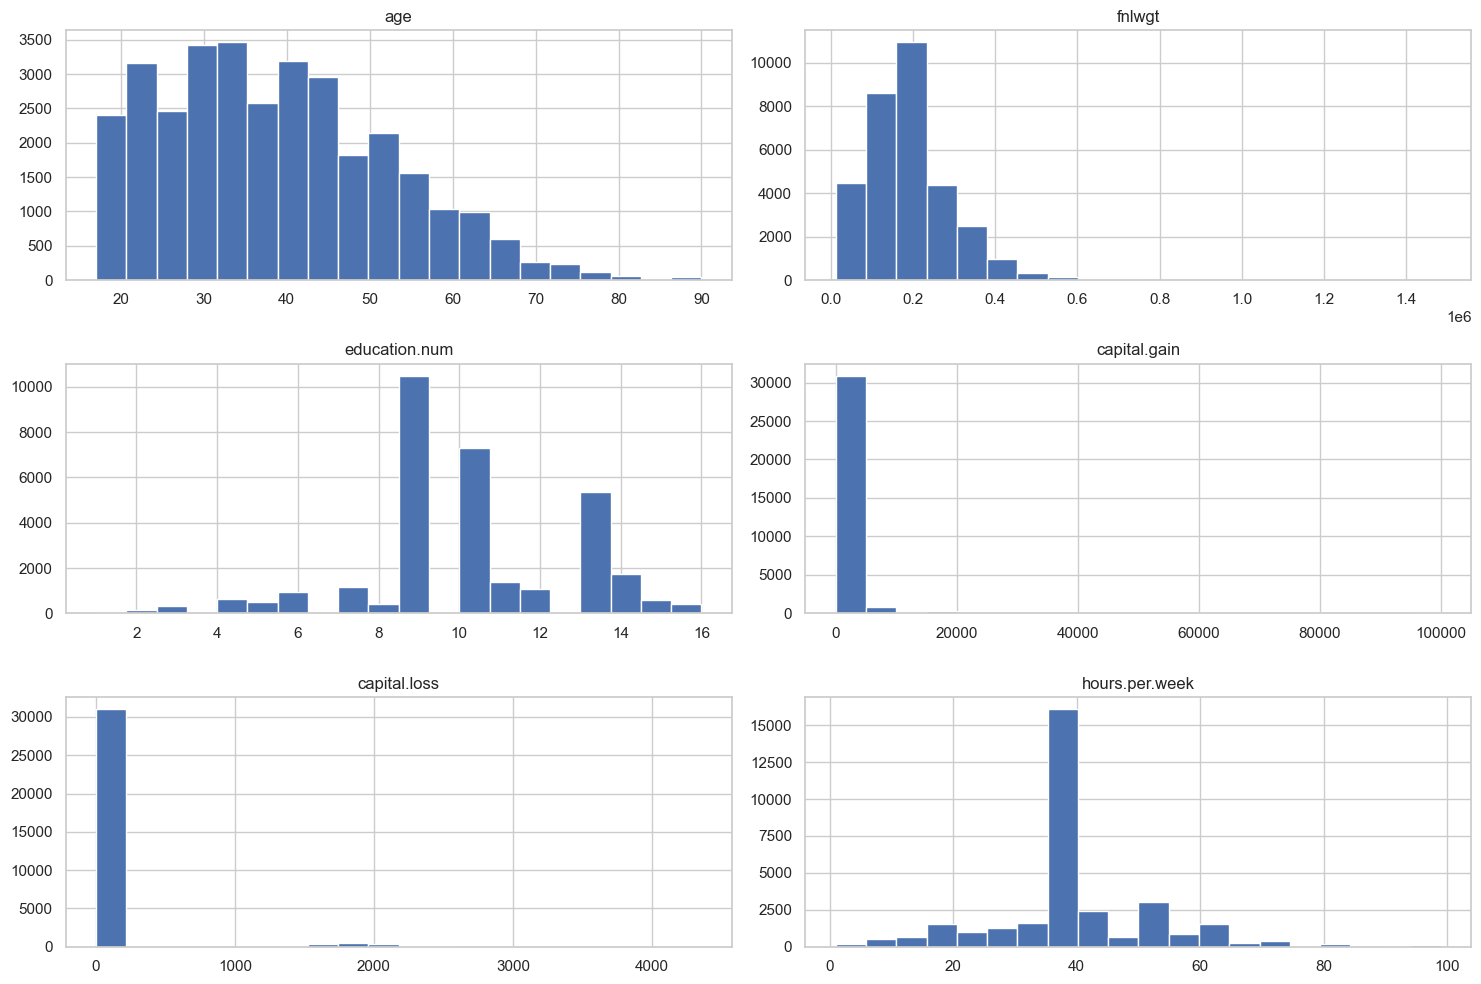

In [19]:
## Visualización de distribuciones numéricas
df[numeric_columns].hist(
    bins=20,
    figsize=(15,10)
)

plt.tight_layout()
plt.show()

In [20]:
## Estadísticas descriptivas de variables numéricas

df[numeric_columns].describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


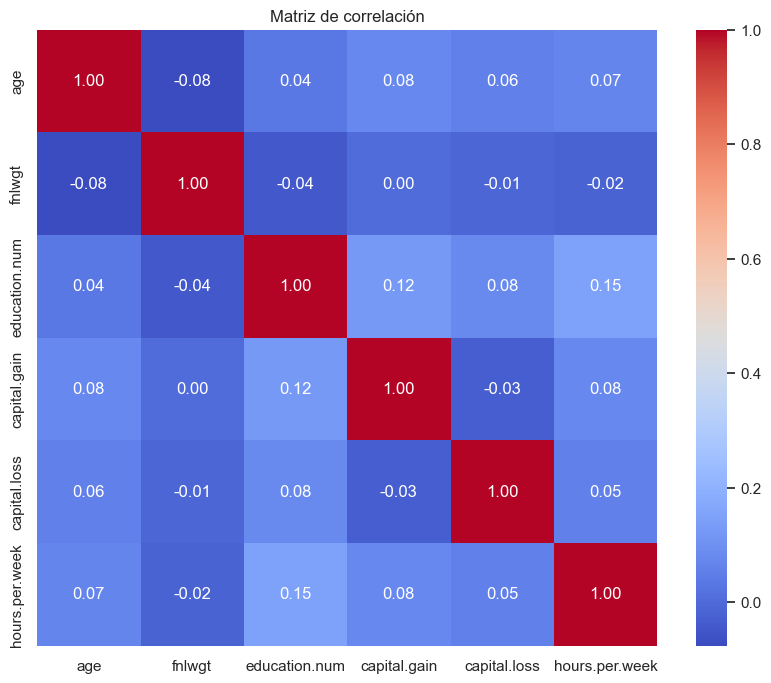

In [36]:
## Matriz de correlación

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Matriz de correlación")
plt.show()

In [37]:
## Selección de variables categóricas

categorical_columns = df.select_dtypes(include=['object']).columns

print(categorical_columns)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='str')


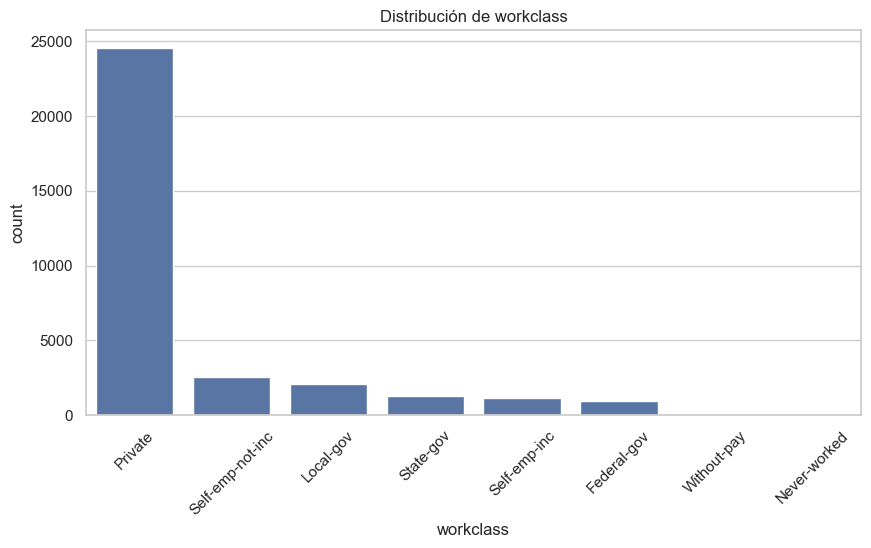

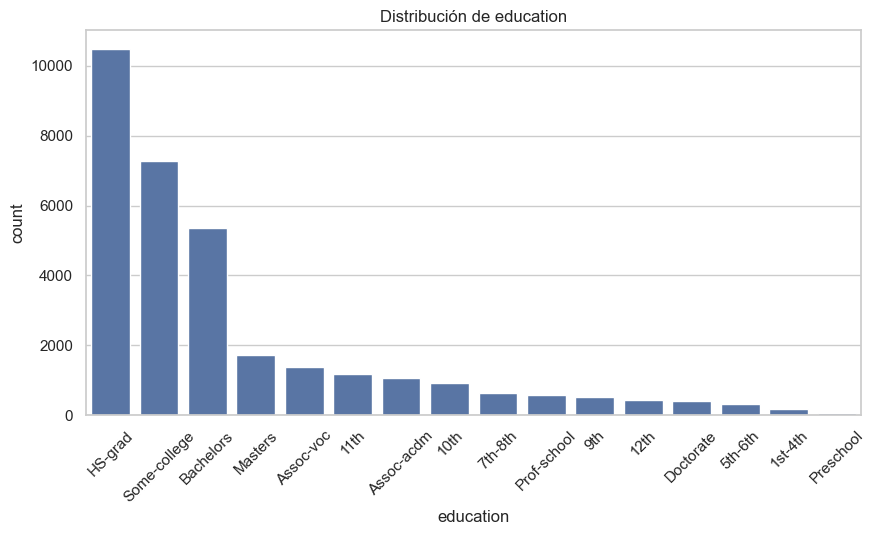

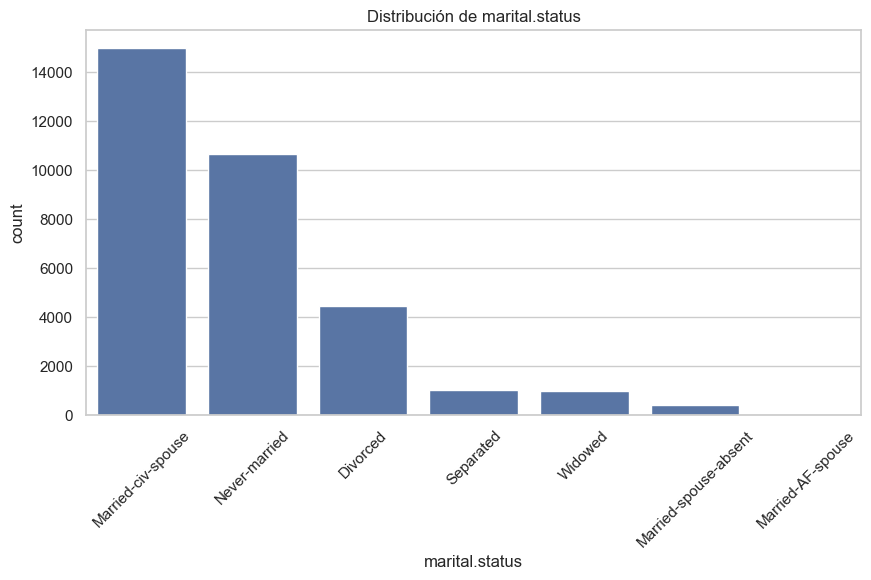

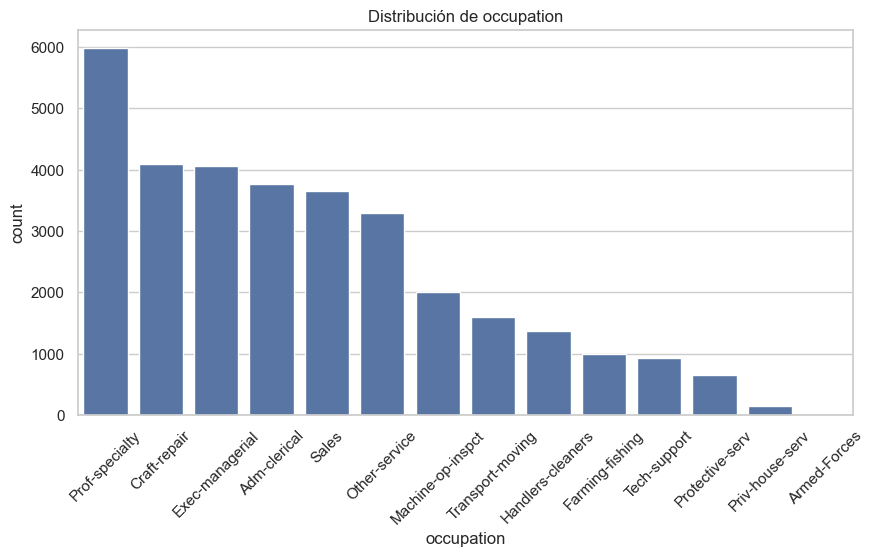

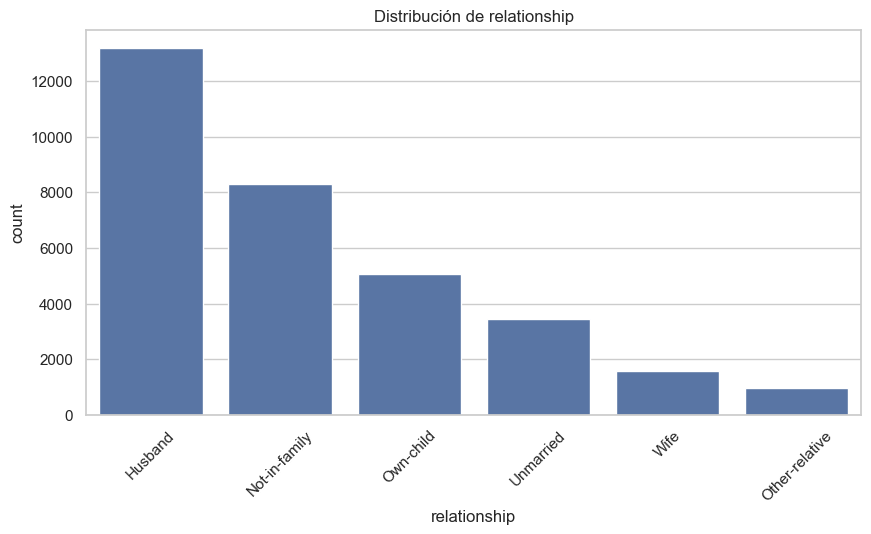

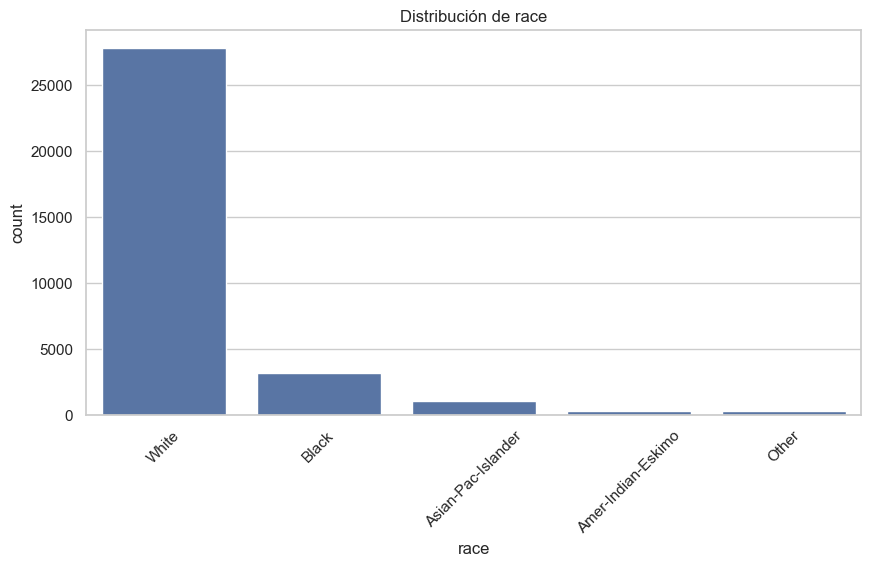

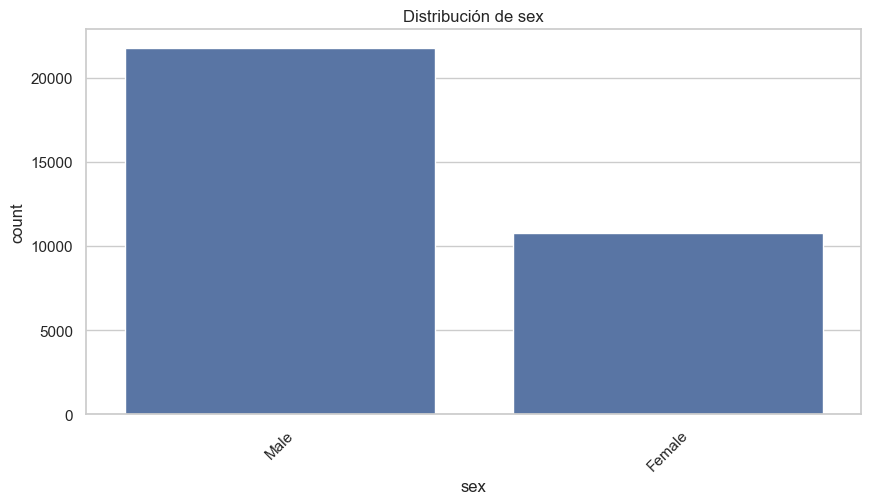

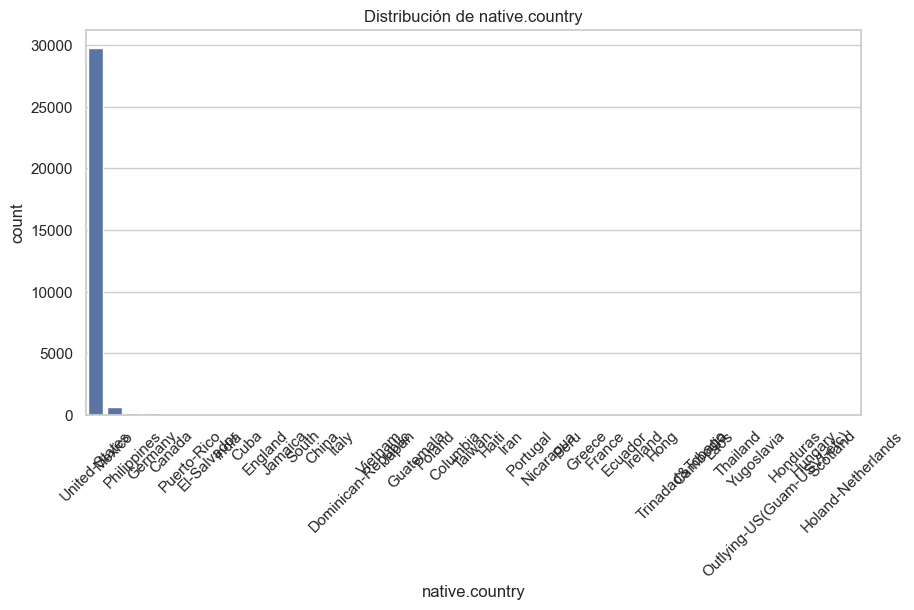

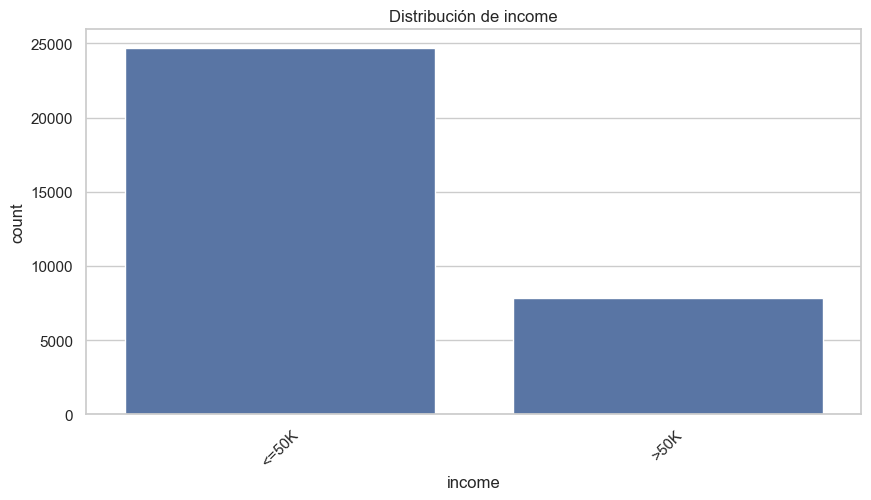

In [38]:
## Distribución de variables categóricas

for column in categorical_columns:

    plt.figure(figsize=(10,5))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    plt.xticks(rotation=45)

    plt.title(f"Distribución de {column}")

    plt.show()

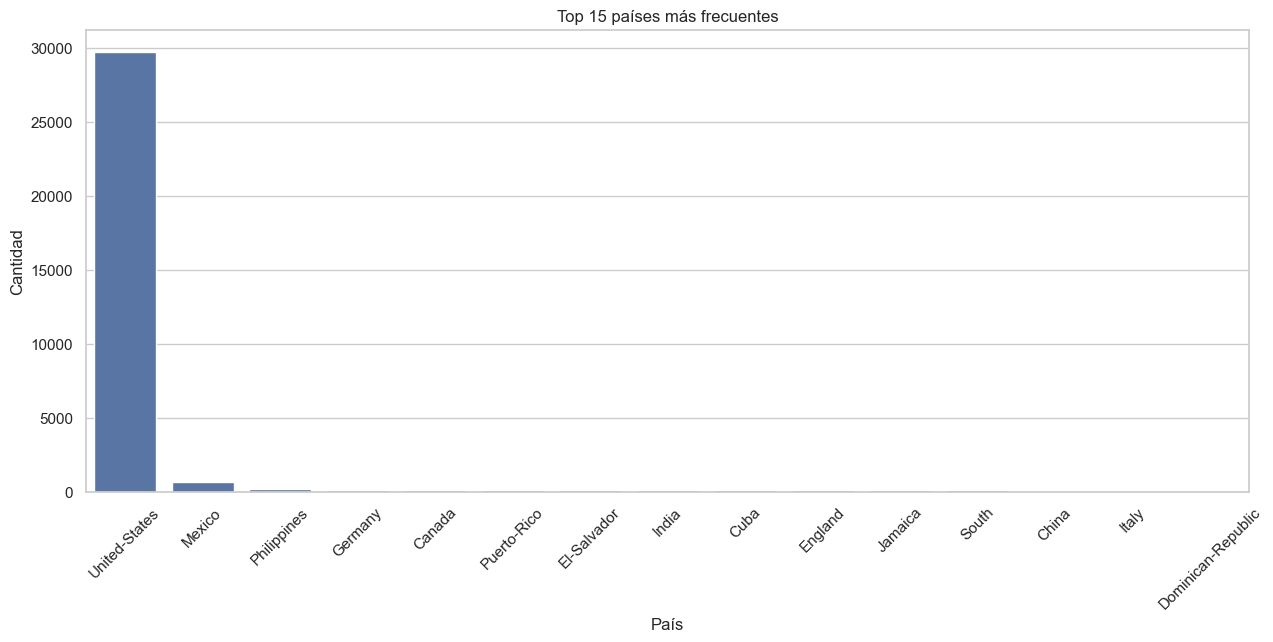

In [39]:
## grafica de natyve.country cambiada ya que la anterior no se ve bien

plt.figure(figsize=(15,6))

top_countries = df["native.country"].value_counts().head(15)

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.xticks(rotation=45)

plt.title("Top 15 países más frecuentes")

plt.xlabel("País")
plt.ylabel("Cantidad")

plt.show()

In [40]:
## Identificación de valores faltantes

df = df.replace("?", np.nan)

In [41]:
## Verificación de valores faltantes

df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [42]:
## Selección actualizada de variables categóricas

categorical_columns = df.select_dtypes(include=['object']).columns

print(categorical_columns)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='str')


In [43]:
## Selección actualizada de variables numéricas

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

print(numeric_columns)

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='str')


In [44]:
## Imputación de variables categóricas

categorical_imputer = SimpleImputer(strategy='most_frequent')

df[categorical_columns] = categorical_imputer.fit_transform(df[categorical_columns])

In [45]:
## Imputación de variables numéricas

numeric_imputer = SimpleImputer(strategy='median')

df[numeric_columns] = numeric_imputer.fit_transform(df[numeric_columns])

In [46]:
## Verificación final de valores faltantes

df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

## Codificación y preparación para Machine Learning

In [47]:
## Aplicación de Label Encoding

label_encoders = {}

for column in categorical_columns:

    encoder = LabelEncoder()

    df[column] = encoder.fit_transform(df[column])

    label_encoders[column] = encoder

In [48]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90.0,3,77053.0,11,9.0,6,9,1,4,0,0.0,4356.0,40.0,38,0
1,82.0,3,132870.0,11,9.0,6,3,1,4,0,0.0,4356.0,18.0,38,0
2,66.0,3,186061.0,15,10.0,6,9,4,2,0,0.0,4356.0,40.0,38,0
3,54.0,3,140359.0,5,4.0,0,6,4,4,0,0.0,3900.0,40.0,38,0
4,41.0,3,264663.0,15,10.0,5,9,3,4,0,0.0,3900.0,40.0,38,0


In [49]:
df.dtypes

age               float64
workclass           int64
fnlwgt            float64
education           int64
education.num     float64
marital.status      int64
occupation          int64
relationship        int64
race                int64
sex                 int64
capital.gain      float64
capital.loss      float64
hours.per.week    float64
native.country      int64
income              int64
dtype: object

### Separación de variables predictoras y variable objetivo


In [ ]:
## Definición de variables X e y

X = df.drop("income", axis=1)

y = df["income"]

In [51]:
## Verificación de dimensiones

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (32537, 14)
Dimensiones de y: (32537,)


In [52]:
## Visualización de variables predictoras

X.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,90.0,3,77053.0,11,9.0,6,9,1,4,0,0.0,4356.0,40.0,38
1,82.0,3,132870.0,11,9.0,6,3,1,4,0,0.0,4356.0,18.0,38
2,66.0,3,186061.0,15,10.0,6,9,4,2,0,0.0,4356.0,40.0,38
3,54.0,3,140359.0,5,4.0,0,6,4,4,0,0.0,3900.0,40.0,38
4,41.0,3,264663.0,15,10.0,5,9,3,4,0,0.0,3900.0,40.0,38


In [53]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: income, dtype: int64

### Escalado y verificación final del dataset

In [54]:
## Aplicación de StandardScaler

scaler = StandardScaler()

X[numeric_columns] = scaler.fit_transform(X[numeric_columns])

In [55]:
## Verificación del escalado
X.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,3.770003,3,-1.067955,11,-0.420679,6,9,1,4,0,-0.145975,10.589625,-0.035664,38
1,3.183397,3,-0.539159,11,-0.420679,6,3,1,4,0,-0.145975,10.589625,-1.817516,38
2,2.010185,3,-0.035241,15,-0.031815,6,9,4,2,0,-0.145975,10.589625,-0.035664,38
3,1.130276,3,-0.468210,5,-2.364998,0,6,4,4,0,-0.145975,9.458380,-0.035664,38
4,0.177041,3,0.709415,15,-0.031815,5,9,3,4,0,-0.145975,9.458380,-0.035664,38


In [56]:
## Verificación de dimensiones finales

print("Dimensiones finales de X:", X.shape)
print("Dimensiones finales de y:", y.shape)

Dimensiones finales de X: (32537, 14)
Dimensiones finales de y: (32537,)


In [57]:
X.dtypes

age               float64
workclass           int64
fnlwgt            float64
education           int64
education.num     float64
marital.status      int64
occupation          int64
relationship        int64
race                int64
sex                 int64
capital.gain      float64
capital.loss      float64
hours.per.week    float64
native.country      int64
dtype: object

In [58]:
X.describe()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
count,3.253700e+04,32537.000000,3.253700e+04,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,3.253700e+04,3.253700e+04,3.253700e+04,32537.000000
mean,-7.686973e-17,3.094446,-1.237122e-16,10.297507,2.096447e-17,2.611427,6.139288,1.446538,3.665827,0.669238,-2.795263e-17,2.795263e-17,-6.988157e-17,36.419184
std,1.000015e+00,1.107549,1.000015e+00,3.870142,1.000015e+00,1.506301,3.973173,1.607064,0.848847,0.470495,1.000015e+00,1.000015e+00,1.000015e+00,6.053816
min,-1.582777e+00,0.000000,-1.681551e+00,0.000000,-3.531590e+00,0.000000,0.000000,0.000000,0.000000,0.000000,-1.459754e-01,-2.167432e-01,-3.194403e+00,0.000000
25%,-7.761933e-01,3.000000,-6.816726e-01,9.000000,-4.206787e-01,2.000000,3.000000,0.000000,4.000000,0.000000,-1.459754e-01,-2.167432e-01,-3.566374e-02,38.000000
50%,-1.162616e-01,3.000000,-1.082361e-01,11.000000,-3.181473e-02,2.000000,6.000000,1.000000,4.000000,1.000000,-1.459754e-01,-2.167432e-01,-3.566374e-02,38.000000
75%,6.903217e-01,3.000000,4.472760e-01,12.000000,7.459132e-01,4.000000,9.000000,3.000000,4.000000,1.000000,-1.459754e-01,-2.167432e-01,3.693028e-01,38.000000
max,3.770003e+00,7.000000,1.226778e+01,15.000000,2.301369e+00,6.000000,13.000000,5.000000,4.000000,1.000000,1.338964e+01,1.058963e+01,4.742941e+00,40.000000
